In [1]:
import uproot
import numpy as np
import mplhep as hep
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
control_dc: str = "/eos/user/s/scrossle/hh_output/NN_roster/fits/Modelmulti_HH_ttbar_tW_WJets_Others/era_2022/SL_res_2b_DNN_ttbar/Scorettbar.root"
signal_dc: str = "/eos/user/s/scrossle/hh_output/NN_roster/fits/Modelmulti_HH_ttbar_tW_WJets_Others/era_2022/SL_res_2b_DNN_HH/ScoreHH.root"

def get_hists(dc: str):
    with uproot.open(dc) as f:
        hists = { n.strip(';1') : (f[n].values(), np.arange(0,len(f[n].axis().edges()))) for n in f.classnames()}
    sig = hists.pop('HH')
    asimov = hists.pop('asimov')
    return sig, hists

Text(1, 0, 'DNN t$\\bar t$ score bin / a.u.')

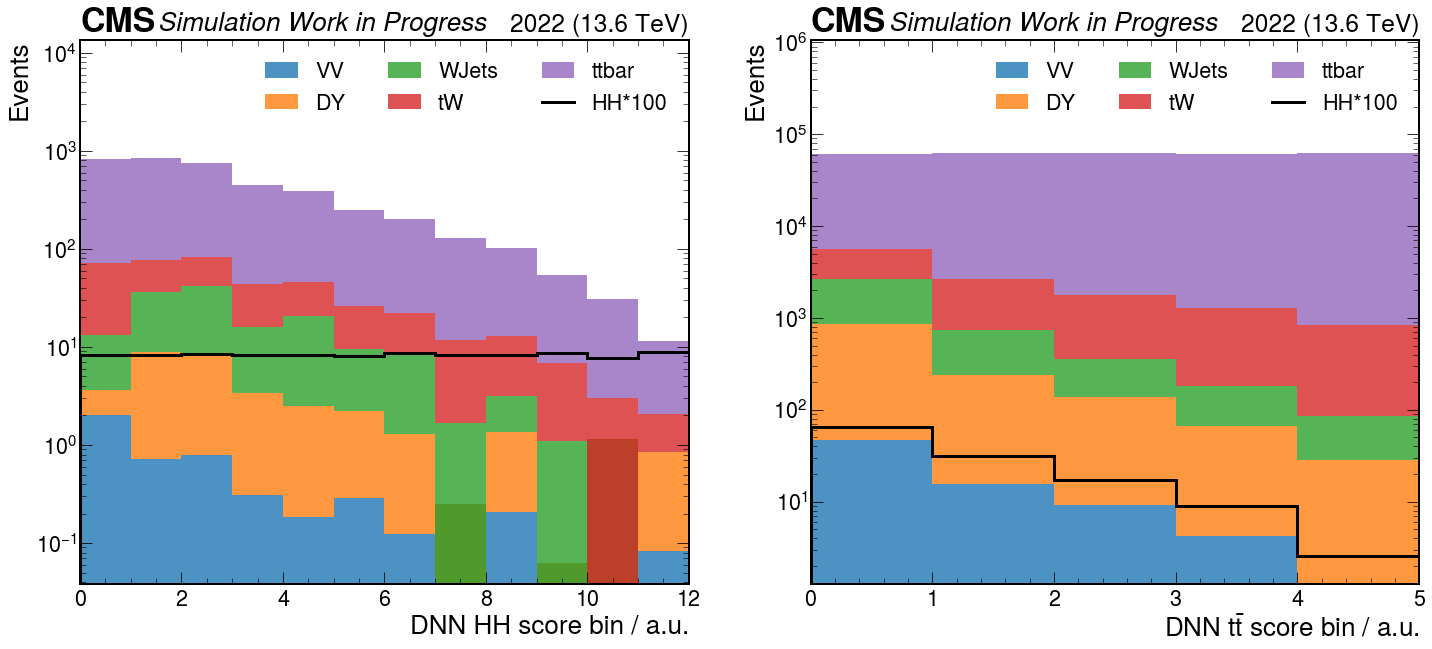

In [5]:
signal_multiplier = 100 
fig, axs = plt.subplots(1,2, figsize=(24,10))
hep.style.use('CMS')

for ax, dc in zip(axs, [signal_dc, control_dc]):
    sig, bkg_dict = get_hists(dc)
    hep.histplot(list(bkg_dict.values()), ax=ax, histtype='fill', label=bkg_dict.keys(), stack=True, sort='y', alpha=0.8)
    hep.histplot((sig[0]*signal_multiplier, sig[1]), ax=ax, label=f'HH*{signal_multiplier}', lw=3, color='k')
    hep.cms.label(loc=0, ax=ax, label='Work in Progress', year='2022', com='13.6')
    ax.set_ylabel('Events')
    ax.set_yscale('log')
    ax.set_xlim(0,sig[1][-1])
    ax.set_ylim(None, ax.get_ylim()[1]*10)
    ax.legend(ncol=(len(bkg_dict)+1)//2)
axs[0].set_xlabel(r'DNN HH score bin / a.u.')
axs[1].set_xlabel(r'DNN t$\bar t$ score bin / a.u.')
